# 🧠 The Mind of a Model
# Day 1: Introduction to the ML Pipeline

In [ ]:
import pandas as pd
import numpy as np

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
url = 'https://raw.githubusercontent.com/Aeshwa-Kachhadiya/The-mind-of-a-model/main/dataset/linkedin_post_performance.xlsx'

df = pd.read_excel(url)
print('✅ Dataset loaded!')
print(f'Shape: {df.shape}')

✅ Dataset loaded!
Shape: (300, 20)


In [ ]:
# STAGE 1: DATA COLLECTION
# This is our dataset
# 300 rows. 20 features.
# Goal: Predict if a LinkedIn post will go viral

print('STAGE 1: DATA COLLECTION')
print()
print(f'Dataset: LinkedIn Post Performance')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()
df.head()

STAGE 1: DATA COLLECTION

Dataset: LinkedIn Post Performance
Rows: 300
Columns: 20



,word_count,has_image,has_video,has_carousel,has_hashtags,hashtag_count,has_question,has_emoji,topic_category,posting_day,posting_hour,is_weekend,account_followers,account_age_months,posting_frequency,likes_first_hour,comments_first_hour,shares_first_hour,impressions_first_hour,went_viral
0,152.0,Yes,No,No,Yes,6,Yes,Yes,Tech,Wednesday,20,No,5822.0,21,1,185.0,48,21,1889.0,Yes
1,485.0,No,No,No,Yes,8,Yes,No,Motivation,Thursday,10,No,4544.0,59,13,98.0,30,5,3726.0,No
2,398.0,Yes,Yes,No,Yes,7,No,Yes,Tech,Tuesday,12,No,7718.0,56,2,2.0,28,2,116.0,No
3,320.0,Yes,No,No,Yes,9,No,Yes,ML,Saturday,4,Yes,4047.0,22,2,196.0,4,12,4448.0,Yes
4,156.0,No,Yes,Yes,No,0,No,Yes,Personal,Monday,0,No,1776.0,36,3,84.0,24,15,564.0,No


In [ ]:
# STAGE 2: PREPROCESSING
# Quick look at what needs cleaning
# Deep cleaning happens on Day 2

print('STAGE 2: PREPROCESSING')
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('We will fix all of this on Day 2.')

STAGE 2: PREPROCESSING

Missing values per column:
word_count                10
has_image                  0
has_video                  0
has_carousel               0
has_hashtags               0
hashtag_count              0
has_question               0
has_emoji                  0
topic_category             0
posting_day                0
posting_hour               0
is_weekend                 0
account_followers         20
account_age_months         0
posting_frequency          0
likes_first_hour          15
comments_first_hour        0
shares_first_hour          0
impressions_first_hour    12
went_viral                 0
dtype: int64

We will fix all of this on Day 2.


In [ ]:
# STAGE 3: FEATURE ENGINEERING
# Quick look at data types
# Deep feature engineering happens on Day 3

print('STAGE 3: FEATURE ENGINEERING')
print()
print('Data types:')
print(df.dtypes)
print()
print('Yes/No columns need to become 1/0.')
print('Text columns need to become numbers.')
print('We will do all of this on Day 3.')

STAGE 3: FEATURE ENGINEERING

Data types:
word_count                float64
has_image                  object
has_video                  object
has_carousel               object
has_hashtags               object
hashtag_count               int64
has_question               object
has_emoji                  object
topic_category             object
posting_day                object
posting_hour                int64
is_weekend                 object
account_followers         float64
account_age_months          int64
posting_frequency           int64
likes_first_hour          float64
comments_first_hour         int64
shares_first_hour           int64
impressions_first_hour    float64
went_viral                 object
dtype: object

Yes/No columns need to become 1/0.
Text columns need to become numbers.
We will do all of this on Day 3.


In [ ]:
# STAGE 4: MODEL TRAINING
# Just showing what training looks like
# Deep model building happens on Day 4

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Minimal preparation just for demo
df_demo = df.copy()

binary_cols = ['has_image', 'has_video', 'has_carousel',
               'has_hashtags', 'has_question', 'has_emoji',
               'is_weekend']
for col in binary_cols:
    df_demo[col] = df_demo[col].map({'Yes': 1, 'No': 0})

df_demo['went_viral'] = df_demo['went_viral'].map(
    {'Yes': 1, 'No': 0})

le = LabelEncoder()
df_demo['topic_category'] = le.fit_transform(
    df_demo['topic_category'])
df_demo['posting_day'] = le.fit_transform(
    df_demo['posting_day'])

numerical_cols = ['word_count', 'account_followers',
                  'account_age_months', 'posting_frequency',
                  'likes_first_hour', 'comments_first_hour',
                  'shares_first_hour', 'impressions_first_hour']
for col in numerical_cols:
    df_demo[col].fillna(df_demo[col].median(), inplace=True)

X = df_demo.drop(columns=['went_viral'])
y = df_demo['went_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print('STAGE 4: MODEL TRAINING')
print()
print('model.fit() has been called.')
print('The model is learning from the data.')
print()
print('Deep model building happens on Day 4.')

/tmp/ipykernel_27538/2909747333.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_demo[col].fillna(df_demo[col].median(), inplace=True)


STAGE 4: MODEL TRAINING

model.fit() has been called.
The model is learning from the data.

Deep model building happens on Day 4.


In [ ]:
# STAGE 5: EVALUATION
# Just showing the accuracy
# Deep evaluation happens on Day 5

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('STAGE 5: EVALUATION')
print()
print(f'Model Accuracy: {accuracy:.2%}')
print()
print('Is this good or bad?')
print('We will find out on Day 5.')

STAGE 5: EVALUATION

Model Accuracy: 85.00%

Is this good or bad?
We will find out on Day 5.


In [ ]:
# STAGE 6: DEPLOYMENT
# Just showing the concept
# Full deployment happens on Day 9

import pickle

with open('model_pipeline_demo.pkl', 'wb') as f:
    pickle.dump(model, f)

print('STAGE 6: DEPLOYMENT')
print()
print('✅ Model saved as model_pipeline_demo.pkl')
print()
print('On Day 9 we will turn this into')
print('a real web application.')

STAGE 6: DEPLOYMENT

✅ Model saved as model_pipeline_demo.pkl

On Day 9 we will turn this into
a real web application.


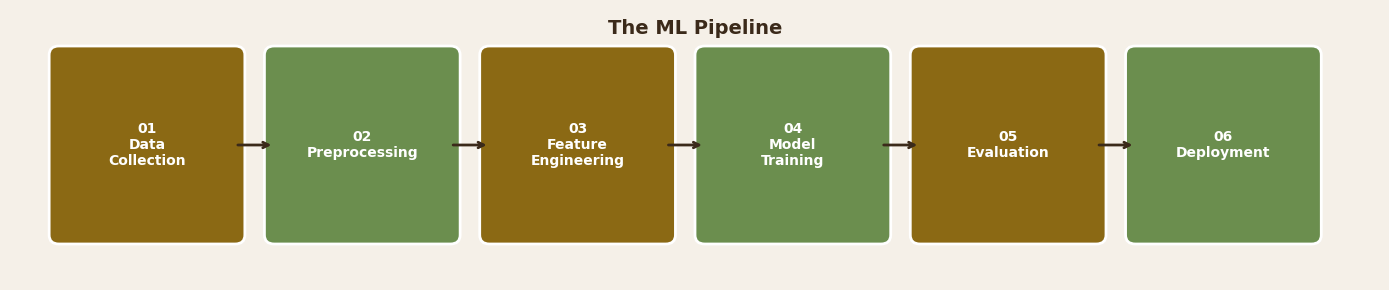

✅ Pipeline visual saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis('off')
fig.patch.set_facecolor('#F5F0E8')

stages = [
    ('01\nData\nCollection', '#8B6914'),
    ('02\nPreprocessing', '#6B8E4E'),
    ('03\nFeature\nEngineering', '#8B6914'),
    ('04\nModel\nTraining', '#6B8E4E'),
    ('05\nEvaluation', '#8B6914'),
    ('06\nDeployment', '#6B8E4E')
]

for i, (label, color) in enumerate(stages):
    x = i * 2.2 + 0.5

    rect = mpatches.FancyBboxPatch(
        (x, 0.5), 1.8, 2,
        boxstyle='round,pad=0.1',
        facecolor=color,
        edgecolor='white',
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(x + 0.9, 1.5, label,
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='white')

    if i < len(stages) - 1:
        ax.annotate('',
                    xy=(x + 2.2, 1.5),
                    xytext=(x + 1.8, 1.5),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='#3B2A1A',
                        lw=2))

ax.text(7, 2.8,
        'The ML Pipeline',
        ha='center', va='center',
        fontsize=14, fontweight='bold',
        color='#3B2A1A')

plt.tight_layout()
plt.savefig('pipeline_visual.png',
            bbox_inches='tight',
            dpi=150,
            facecolor='#F5F0E8')
plt.show()
print('✅ Pipeline visual saved!')